In [2]:
# import os
# os.environ.pop("MPLBACKEND", None)

import numpy as np
import matplotlib.pyplot as plt

In [3]:
# input constants

#ambient air temp
T_amb = 20 #C

#initial temps
T0_cell = 20 #C
T0_copper = 20 #C
T0_aluminum = 20 #C

#specific heat capacities
C_cell = 774 #J/kg*K
C_copper = 385 #J/kg*K
C_aluminum = 900 #J/kg*K
C_air = 718 #J/kg*K

#conduction coefs
K_copper = 400 #W/m*K
K_tim = 6
K_aluminum = 138
K_cell_to_copper = 50 #W/K TODO: test this value, distance agnostic, area agnostic (defined by spot welds)
K_module_to_aluminum = 100 #W/m^2*K TODO: test this value, distance agnostic (defined by thermal stack setup)

#convection coefs
h_cell_to_air = 5 #W/m^2*K TODO: test this value
h_aluminum_to_air = 10 #W/m^2 * K TODO: test this value

#electrical resistivity
resistivity_copper = 1.724e-8 #ohm * m

#cell internal resistance
R_cell = 4e-3 #ohm 

#density and mass
rho_copper = 8960 #kg/m^3
rho_aluminum = 2680
rho_air = 1.225
m_cell = 0.071 #kg


# dimensions
width_busbar = 0.08 #m
length_busbar = 0.02
thickness_busbar = 0.0001

thickness_tim = 0.0015 

area_aluminum = 0.02 #m^2 TODO: check in cad
thickness_aluminum = 0.0254 #m

thermal_contact_area = .015 #m^2

SA_cell = 0.00472 #m^2

air_vol_module = 2.88e-4 #m^3 TODO: check in cad
air_vol_pack = 0.004 #m^3 TODO: check in cad

module_air_area = 0.024 #m^2 both side walls along cells TODO: check in cad

# pack config
cell_count = 40

In [4]:
#calculated constants
# electrical resistances
R_busbar = resistivity_copper * length_busbar / (width_busbar * thickness_busbar) #ohm
R_1s4p = R_cell / 4
R_module = (10 * R_1s4p) + (11 * R_busbar) #ohm

#mass
m_busbar = width_busbar * length_busbar * thickness_busbar * rho_copper #kg

#specific heat capacity

In [ ]:
# ohmic heating
dt = 0.1 #sec
num_steps = 6000

#current schedule
amps = 70 #A
A = np.ones(num_steps) * amps

#initial conditions
T_module = T0_cell
T_busbar = T0_copper
T_aluminum_end = T0_aluminum
T_aluminum_side = T0_aluminum
T_internal_air = T_amb

#temp logs
temp_module = []
temp_busbar = []
temp_aluminum_end = []
temp_aluminum_side = []
temp_internal_air = []

# cell and tab
for i in range(num_steps):

    #cells and tabs aka module
    Q_ohmic_in = A[i] * A[i] * R_module
    # print(Q_ohmic_in)
    Q_cell_conv_out = h_cell_to_air * SA_cell * (T_module - T_internal_air)
    Q_cell_cond_out = K_module_to_aluminum * thermal_contact_area * (T_module - T_aluminum_end)

    Q_module_total = Q_ohmic_in - Q_cell_cond_out - Q_cell_conv_out

    module_dT = (Q_module_total * dt) / (C_cell * m_cell * cell_count)

    T_module += module_dT
    temp_module.append(T_module)

    #internal air
    Q_internal_air_conv_out = h_aluminum_to_air * module_air_area * (T_internal_air - T_aluminum_side)
    
    Q_module_air_total = Q_cell_conv_out - Q_internal_air_conv_out

    internal_air_dT = (Q_module_air_total * dt) / (C_air * air_vol_module * rho_air)

    T_internal_air += internal_air_dT
    temp_internal_air.append(T_internal_air)

    #aluminum end
    Q_end_conv_out = h_aluminum_to_air * area_aluminum * (T_aluminum_end - T_amb)

    Q_end_total = Q_cell_cond_out - Q_end_conv_out

    end_dT = (Q_end_total * dt) / (C_aluminum * area_aluminum * thickness_aluminum * rho_aluminum)

    T_aluminum_end += end_dT
    temp_aluminum_end.append(T_aluminum_end)
    
    

51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
51.32309
5

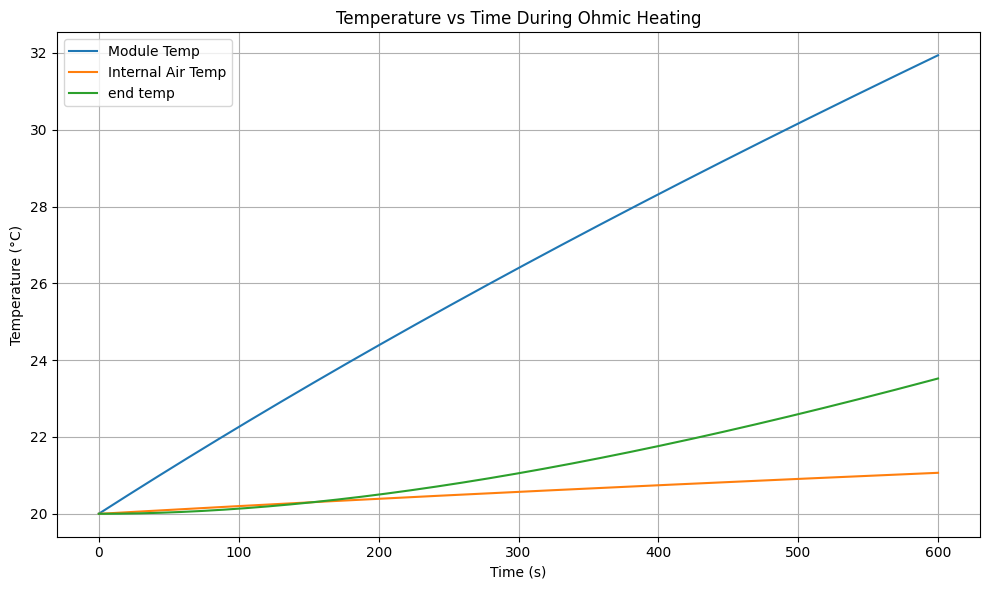

In [6]:
# Time vector
time = np.arange(num_steps) * dt

# Plot temperatures vs time
plt.figure(figsize=(10, 6))

plt.plot(time, temp_module, label='Module Temp')
plt.plot(time, temp_internal_air, label='Internal Air Temp')
plt.plot(time,temp_aluminum_end, label='end temp')

# Optional if you later populate these lists
if len(temp_busbar) > 0:
    plt.plot(time[:len(temp_busbar)], temp_busbar, label='Busbar Temp')

if len(temp_aluminum_side) > 0:
    plt.plot(time[:len(temp_aluminum_side)], temp_aluminum_side, label='Aluminum Side Temp')

plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Time During Ohmic Heating')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()